In [8]:
from typing import Dict, List
from model_ranking import (
    get_transformer_results_aug_sweep,
    extract_values_at_index,
    plot_performance_vs_transfer_metric,
)

In [9]:
selected_augmentations: Dict[str, List[str]] = {
    "none": [],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", "a015-02"],
}
source_models = {
    "Micro_SAM": ['vit_t_lm', 'vit_b_lm', 'vit_l_lm'],
    "SAM": ['vit_t', 'vit_b', 'vit_l']
}

In [10]:
direct_eval_results, p_eval_results, consis_results = get_transformer_results_aug_sweep(
    source_models=source_models,
    selected_augmentations=selected_augmentations,
    eval_key="mSA_scores_median",
)

Augmentation type: none
Augmentation type: gauss
  Index 0: Alpha a001-003


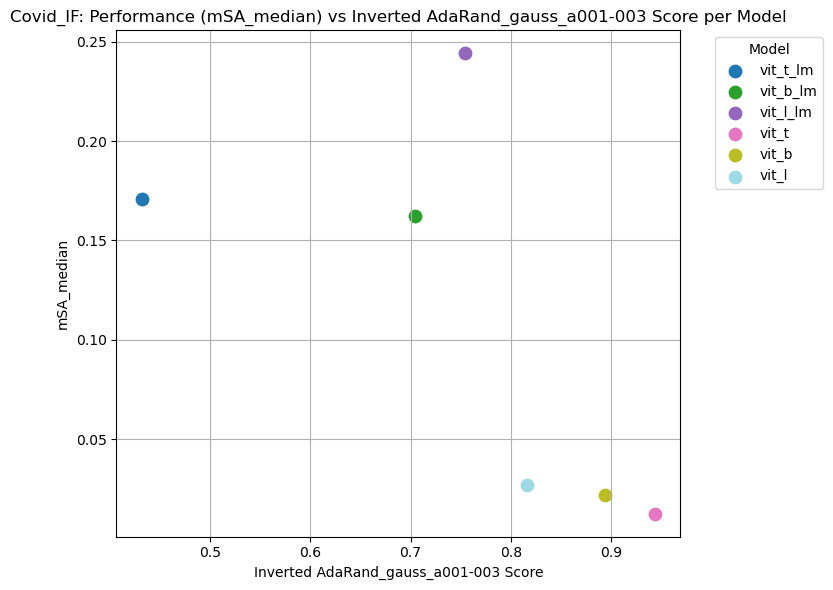

  Index 1: Alpha a003-005


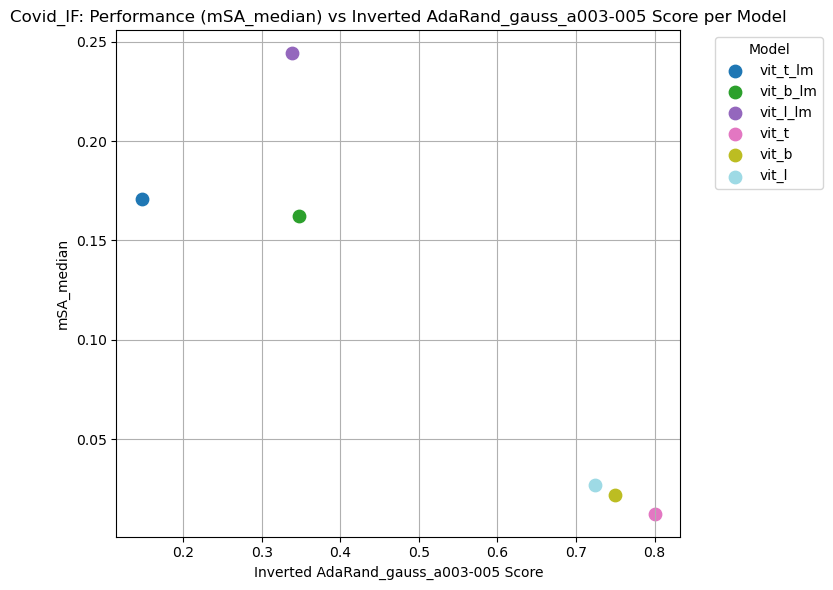

  Index 2: Alpha a005-007


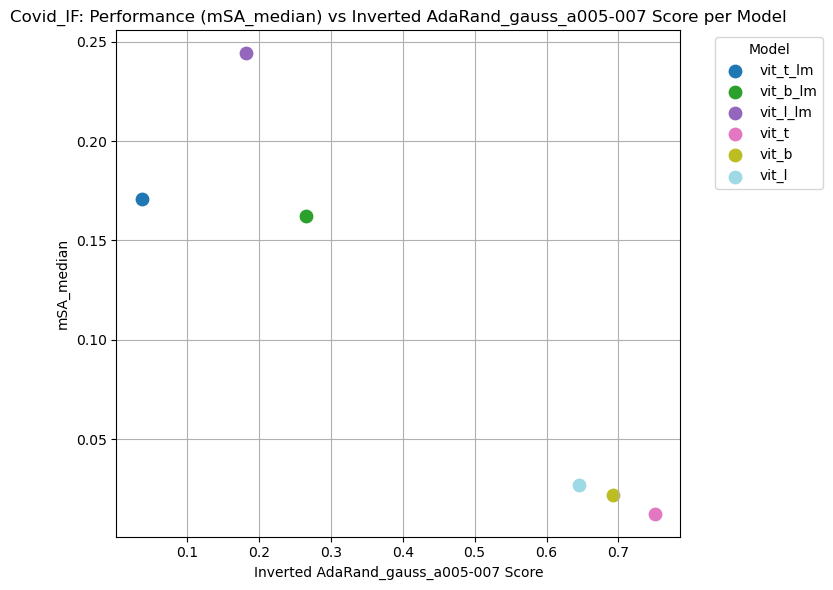

  Index 3: Alpha a007-01


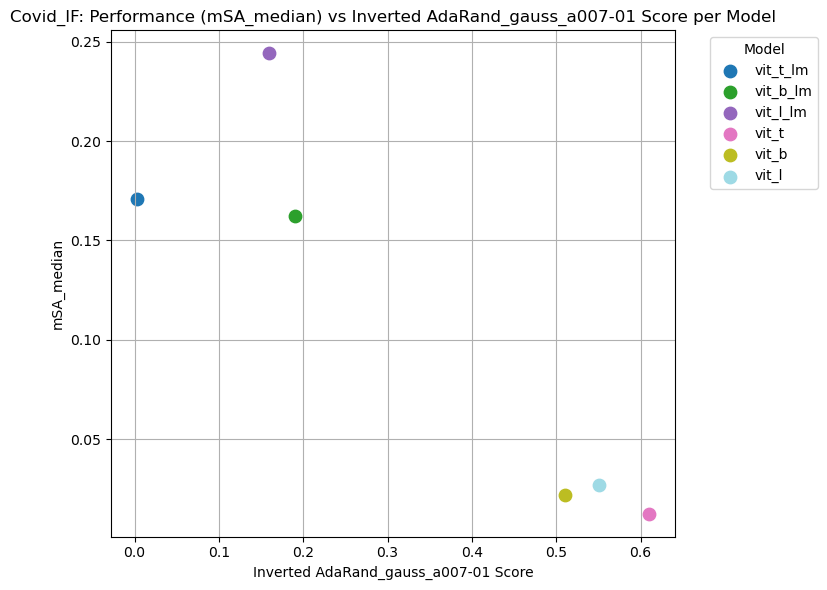

  Index 4: Alpha a01-012


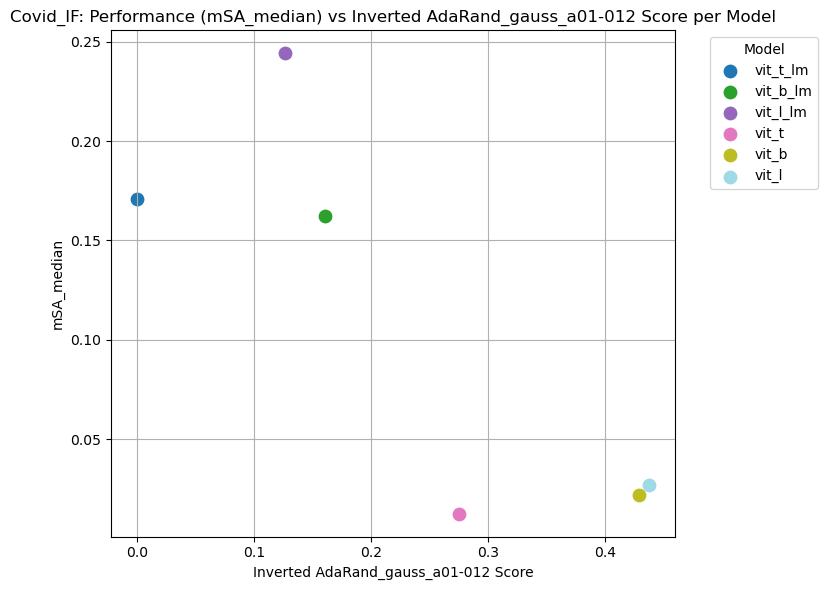

  Index 5: Alpha a012-015


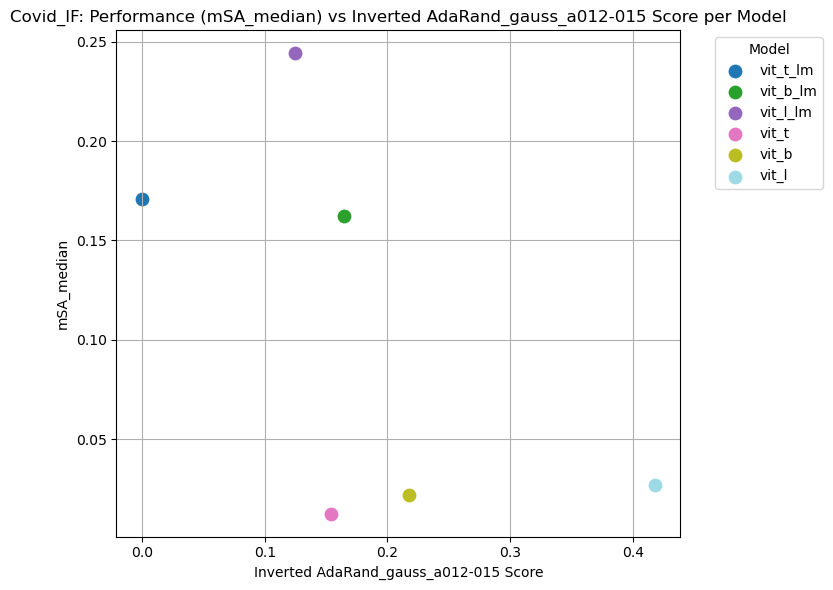

  Index 6: Alpha a015-02


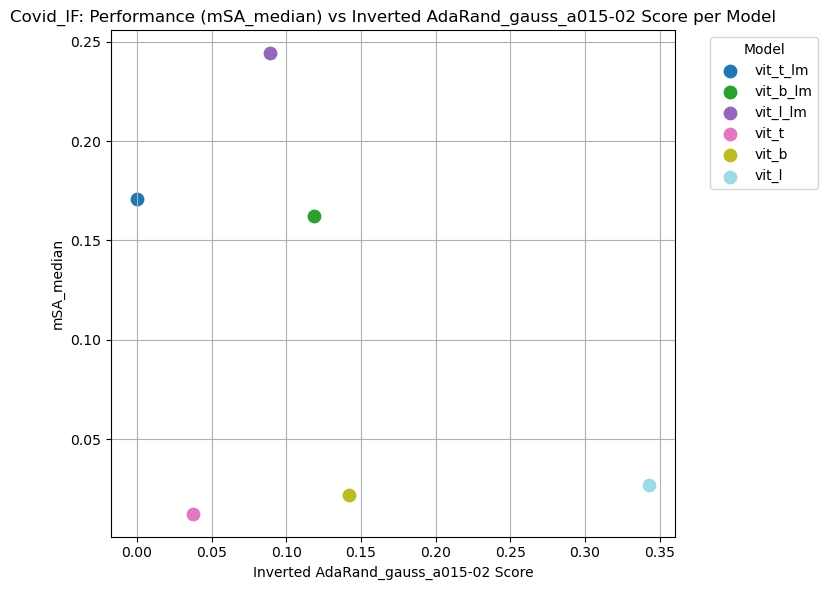

In [11]:
for aug_type, alphas in selected_augmentations.items():
    print(f"Augmentation type: {aug_type}")
    for i, alpha in enumerate(alphas):
        print(f"  Index {i}: Alpha {alpha}")

        consis_scores = extract_values_at_index(consis_results, aug_type, i)

        _ = plot_performance_vs_transfer_metric(
            performance_scores=direct_eval_results,
            transfer_metrics=consis_scores,
            target="Covid_IF",
            metric_name=f"Inverted AdaRand_{aug_type}_{alpha}",
            performance_metric_name="mSA_median",
            invert_transfer_metric=True,
        )